In [1]:
# ==================== 环境配置 ====================
SITE_ID = "Cockatoo"                
BUILDING_TYPE = "office"       
TARGET = f"{SITE_ID}_{BUILDING_TYPE}_Giovanni"   # 明确目标列名称
DATA_SAVE_PATH = "E:/bishe/preprocessed_data（Cockatoo）.csv"  # 确保路径正确
SOURCE_BUILDINGS = ['Cockatoo_office_Pansy', 'Cockatoo_office_Elbert', 'Cockatoo_office_Delores']

In [2]:
# ==================== 库导入 ====================
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import math
from time import time
import os
from warnings import filterwarnings
filterwarnings('ignore')  


=== 网格搜索预训练 ===
Fitting 3 folds for each of 128 candidates, totalling 384 fits
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0

Best Source Model Parameters: {'feature_fraction': 0.8, 'lambda_l1': 0.1, 'lambda_l2': 0, 'learning_rate': 0.01, 'max_depth': 7, 'min_data_in_leaf': 30, 'num_leaves': 63}

源模型训练耗时: 141.66秒

=== 目标数据处理 ===

=== 开始微调 ===
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000327 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1591
[LightGBM] [Info] Number of data points in the train

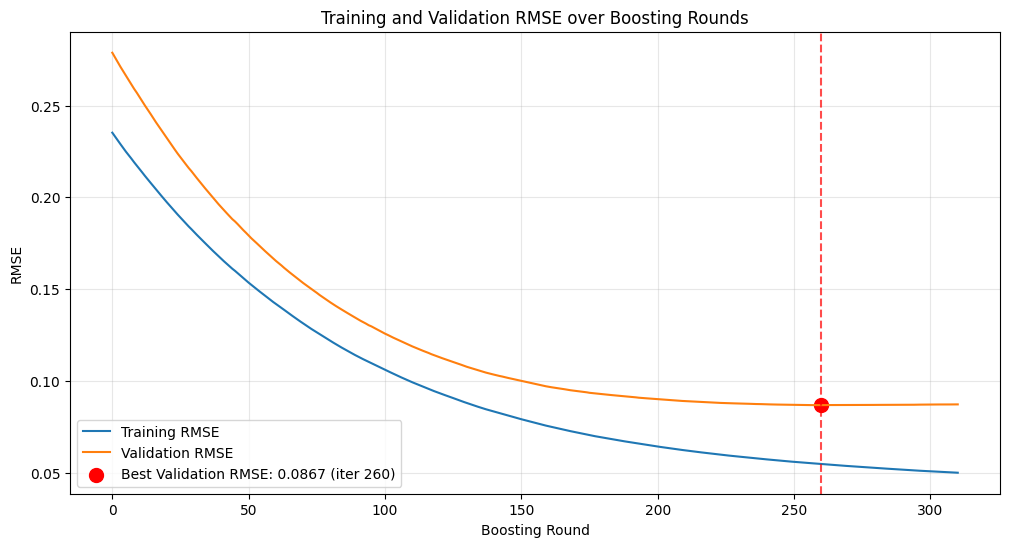


验证集评估结果:
Validation - MSE: 35.28, RMSE: 5.94, CVRMSE: 24.72%, R2: 0.8634, Accuracy: 82.21%


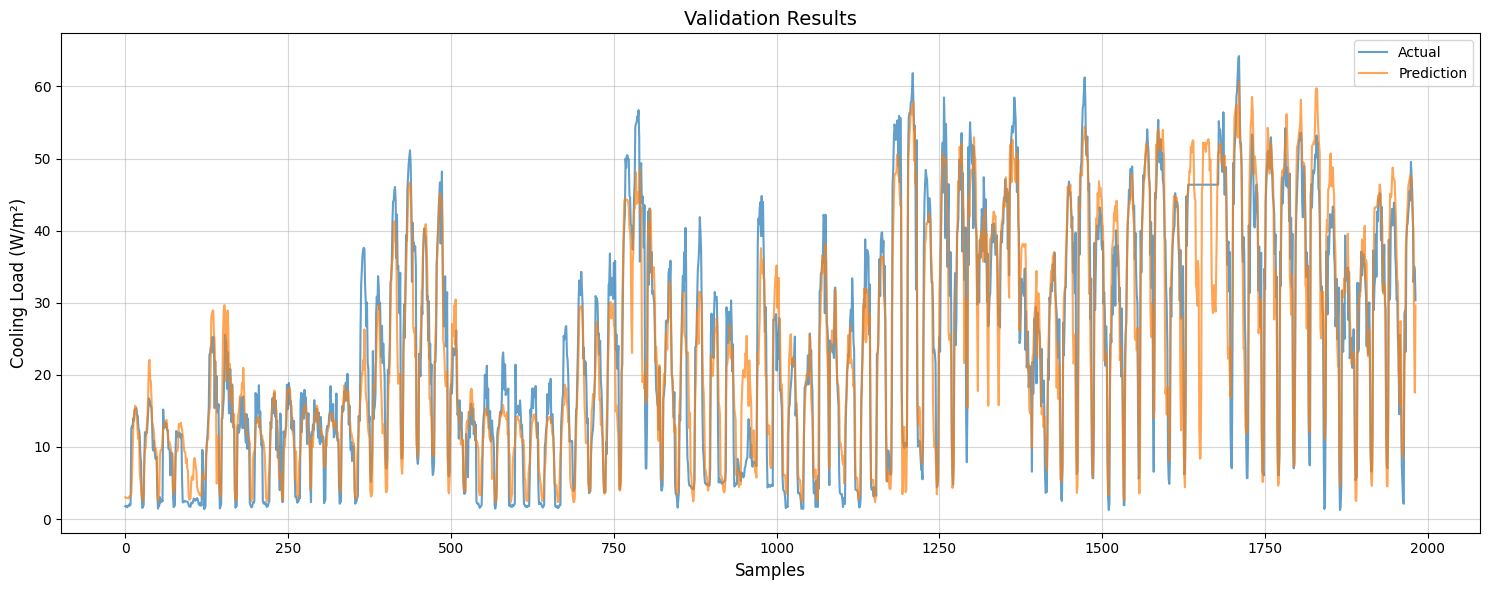


测试集评估结果:
Test - MSE: 27.40, RMSE: 5.23, CVRMSE: 18.40%, R2: 0.8631, Accuracy: 85.67%


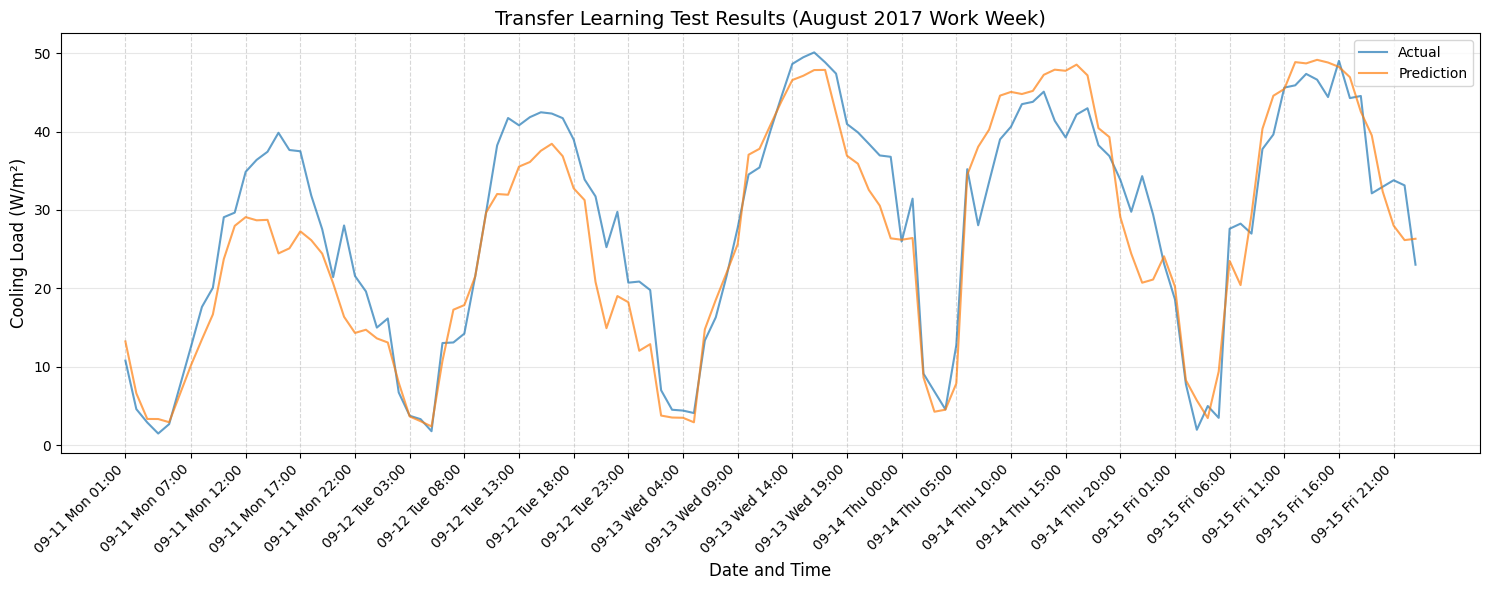

<Figure size 1200x800 with 0 Axes>

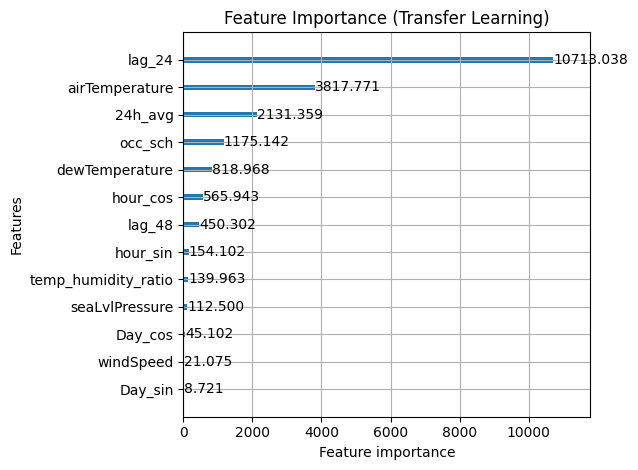

Model saved to 'E:/bishe/transfer_learning_model.txt'

Test Set Details:
Start: 2017-09-11 01:00
End: 2017-09-15 23:00
Days: 5 days
Total hours: 118
Day types: Mon, Tue, Wed, Thu, Fri

Total execution time: 00h:00m:2.79s


In [3]:
# ==================== 辅助函数 ====================
def fill_lag_nan(df, ref_df, target_col):
    """填充滞后特征中的NaN值 - 使用参考数据集（历史数据）"""
    for col in df.columns:
        if 'lag_' in col:
            lag = int(col.split('_')[-1])
            # 使用参考数据集的末尾值来填充
            last_valid = ref_df[target_col].iloc[-lag:].mean()
            df[col] = df[col].fillna(last_valid)
    return df

def clean_data(df):
    """数据清洗：处理NaN和Inf"""
    # 填充NaN
    df = df.fillna(method='ffill').fillna(method='bfill')
    
    # 处理无穷大值
    for col in df.columns:
        if df[col].dtype in [np.float64, np.float32]:
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)
            df[col] = df[col].fillna(df[col].mean())
    return df  

# ==================== 特征工程函数 ====================
def add_features(df, target_col):
    """增强的特征工程 - 确保时间序列正确性"""
    df = df.copy()
    # 时间特征
    df['Hour'] = df['timestamp'].dt.hour
    df['DayOfWeek'] = df['timestamp'].dt.dayofweek
    
    # 周期特征
    df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
    df['Day_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
    df['Day_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
    
    # 滞后特征 - 使用目标列
    for i in [24, 48]:
        df[f'lag_{i}'] = df[target_col].shift(i)
    
    # 移动平均特征
    df['24h_avg'] = df[target_col].rolling(24, min_periods=1).mean()
    
    # 交叉特征
    df['temp_humidity_ratio'] = df['airTemperature'] / (df['dewTemperature'] + 1e-6)
    
    return df.drop(columns=['Hour', 'DayOfWeek'])

# ==================== 数据管道 ====================
def prepare_dataset(buildings, is_source=True):
    """
    数据预处理管道 - 修复时间序列独立性
    :param buildings: 建筑列表（源建筑使用多个，目标建筑使用单个）
    :param is_source: 是否为源数据准备
    """
    raw_data = pd.read_csv(DATA_SAVE_PATH, parse_dates=['timestamp'])
    weather_cols = ['airTemperature', 'dewTemperature', 'windSpeed', 'seaLvlPressure', 'occ_sch']
    
    # 处理每个建筑的数据 - 保持时间序列独立
    dfs = []
    for building in buildings:
        df = raw_data[['timestamp', building] + weather_cols].copy()
        df = df.rename(columns={building: 'target'})
        
        # 按时间排序确保时序正确性
        df = df.sort_values('timestamp')
        
        # 添加特征并清洗
        df = add_features(df, 'target')
        df = clean_data(df)
        
        # 添加建筑标识符
        df['building_id'] = building
        dfs.append(df)
    
    # 合并数据但保持各自时间序列
    combined_df = pd.concat(dfs, axis=0)
    return combined_df  

# ==================== 数据集划分函数 ====================
def split_data_by_month(data, target_col):
    """按照月份划分数据集（使用改进的划分逻辑）"""
    # 按月份划分数据集
    data = data.sort_values('timestamp')
    data['year_month'] = data['timestamp'].dt.to_period('M')
    unique_months = data['year_month'].unique().tolist()
    
    # 数据集划分
    train = data[data['year_month'].isin(unique_months[:15])]  # 前15个月
    val = data[data['year_month'].isin(unique_months[15:19])]  # 接下来5个月
    
    # 使用与改进代码相同的测试时间段
    test_start = pd.Timestamp('2017-09-11 00:00:00')
    test_end = pd.Timestamp('2017-09-16 00:00:00')
    test = data[(data['timestamp'] >= test_start) & (data['timestamp'] < test_end)]
    
    # 保存测试集时间戳
    test_timestamps = test['timestamp'].copy().reset_index(drop=True)
    
    # 定义特征列
    features = [
        'airTemperature', 'dewTemperature', 'windSpeed', 'seaLvlPressure', 'occ_sch',
        'hour_sin', 'hour_cos', 'Day_sin', 'Day_cos', 
        'lag_24', 'lag_48',
        '24h_avg',
        'temp_humidity_ratio'
    ]
    
    # 使用MinMaxScaler进行归一化
    scaler_x = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    # 只使用训练集拟合归一化器
    X_train_scaled = scaler_x.fit_transform(train[features])
    y_train_scaled = scaler_y.fit_transform(train[[target_col]])
    
    X_val_scaled = scaler_x.transform(val[features])
    y_val_scaled = scaler_y.transform(val[[target_col]])
    
    X_test_scaled = scaler_x.transform(test[features])
    y_test_scaled = scaler_y.transform(test[[target_col]])
    
    # 转换为DataFrame并重置索引
    X_train = pd.DataFrame(X_train_scaled, columns=features).reset_index(drop=True)
    X_val = pd.DataFrame(X_val_scaled, columns=features).reset_index(drop=True)
    X_test = pd.DataFrame(X_test_scaled, columns=features).reset_index(drop=True)
    
    y_train = pd.Series(y_train_scaled.ravel()).reset_index(drop=True)
    y_val = pd.Series(y_val_scaled.ravel()).reset_index(drop=True)
    y_test = pd.Series(y_test_scaled.ravel()).reset_index(drop=True)
    
    # 筛选工作日数据（周一至周五）
    work_days_mask = (test_timestamps.dt.dayofweek >= 0) & (test_timestamps.dt.dayofweek <= 4)
    work_timestamps = test_timestamps[work_days_mask].reset_index(drop=True)
    
    # 应用工作日掩码（确保索引对齐）
    X_test = X_test.loc[work_days_mask.values].reset_index(drop=True)
    y_test = y_test.loc[work_days_mask.values].reset_index(drop=True)
    
    return (X_train, X_val, X_test, 
            y_train, y_val, y_test, 
            work_timestamps, scaler_y)  

# ==================== 合并训练源模型 ====================
def train_with_gridsearch():
    """带网格搜索的预训练 - 使用正确的时间序列交叉验证"""
    print("\n=== 网格搜索预训练 ===")
    source_data = prepare_dataset(SOURCE_BUILDINGS)
    
    # 特征配置
    features = [
        'airTemperature', 'dewTemperature', 'windSpeed', 'seaLvlPressure', 'occ_sch',
        'hour_sin', 'hour_cos', 'Day_sin', 'Day_cos',
        'lag_24', 'lag_48',
        '24h_avg',
        'temp_humidity_ratio'
    ]
    
    # 确保数据按时间排序
    source_data = source_data.sort_values('timestamp').reset_index(drop=True)
    
    # 提取特征和目标
    X = source_data[features]
    y = source_data['target']
    
    # 优化参数网格（关键可调区域）
    param_grid = {
        'num_leaves': [63, 127],
        'learning_rate': [0.01, 0.05],
        'max_depth': [7, 9],
        'min_data_in_leaf': [30, 50],
        'lambda_l1': [0, 0.1],
        'lambda_l2': [0, 0.1],
        'feature_fraction': [0.7, 0.8]
    }
    
    # 基础参数（固定部分）
    base_params = {
        'objective': 'regression',
        'metric': 'rmse',
        'n_estimators': 1000,
        'random_state': 42,
        'verbosity': -1,
        'force_col_wise': True
    }
    
    # 正确的时间序列交叉验证
    tscv = TimeSeriesSplit(n_splits=3)
    
    # 执行网格搜索
    model = lgb.LGBMRegressor(**base_params)
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=2
    )
    
    # 使用时间序列交叉验证进行网格搜索
    grid_search.fit(X, y)
    
    # 获取最佳参数
    best_params = grid_search.best_params_
    print(f"\nBest Source Model Parameters: {best_params}")
    
    # 使用最佳参数训练最终模型
    best_model = lgb.LGBMRegressor(**best_params, **base_params)
    best_model.fit(X, y)
    
    return best_model, best_params  

# ==================== 迁移学习微调 ====================
def safe_fine_tune(source_model, source_params, X_train, y_train, X_val, y_val):
    """
    安全微调函数（使用与目标建筑相同的训练参数）
    :param source_model: 预训练模型
    :param source_params: 源模型的最佳参数
    :param X_train: 训练特征
    :param y_train: 训练标签
    :param X_val: 验证特征
    """
    # 使用源模型的最佳参数作为基础
    base_params = source_params.copy()
    
    # 使用与目标建筑相同的训练参数
    tune_params = {
        'learning_rate': 0.01,
        'n_estimators': 500,
        'early_stopping_rounds': 50,
    }
    
    # 更新参数
    base_params.update(tune_params)
    
    # 创建数据集用于评估记录
    train_data = lgb.Dataset(X_train, label=y_train)
    valid_data = lgb.Dataset(X_val, label=y_val)
    
    # 增量训练（使用源模型作为基础）
    evals_result = {}  # 用于记录评估结果
    
    # 确保包含必要的参数
    if 'metric' not in base_params:
        base_params['metric'] = 'rmse'
    if 'objective' not in base_params:
        base_params['objective'] = 'regression'
    
    # 同时监控训练集和验证集
    tuned_model = lgb.train(
        base_params,
        train_data,
        valid_sets=[train_data, valid_data],
        valid_names=['training', 'valid'],
        num_boost_round=base_params['n_estimators'],
        early_stopping_rounds=base_params['early_stopping_rounds'],
        evals_result=evals_result,
        verbose_eval=50,
        init_model=source_model  # 继承预训练权重
    )
    return tuned_model, evals_result  

# ==================== 绘制训练曲线 ====================
def plot_training_history(evals_result, save_path=None):
    """绘制训练损失曲线"""
    if not evals_result:
        print("没有可用的评估结果来绘制训练曲线")
        return

    plt.figure(figsize=(12, 6))
    
    # 提取训练和验证损失
    if 'training' in evals_result and 'valid' in evals_result:
        train_loss = evals_result['training']['rmse']
        val_loss = evals_result['valid']['rmse']
    elif 'train' in evals_result and 'val' in evals_result:
        train_loss = evals_result['train']['rmse']
        val_loss = evals_result['val']['rmse']
    else:
        print("无法找到训练和验证损失数据")
        return

    # 绘制曲线
    plt.plot(train_loss, label='Training RMSE')
    plt.plot(val_loss, label='Validation RMSE')

    # 标记最佳点
    best_iter = np.argmin(val_loss)
    best_val_loss = val_loss[best_iter]
    plt.axvline(x=best_iter, color='r', linestyle='--', alpha=0.7)
    plt.scatter(best_iter, best_val_loss, color='red', s=100,
               label=f'Best Validation RMSE: {best_val_loss:.4f} (iter {best_iter})')

    plt.legend()
    plt.title('Training and Validation RMSE over Boosting Rounds')
    plt.xlabel('Boosting Round')
    plt.ylabel('RMSE')
    plt.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()  

# ==================== 主程序 ====================
if __name__ == "__main__":
    # 阶段1：合并训练源模型
    start_time = time()
    source_model, source_params = train_with_gridsearch()
    print(f"\n源模型训练耗时: {time()-start_time:.2f}秒")
    
    # 阶段2：目标数据准备
    print("\n=== 目标数据处理 ===")
    target_data = prepare_dataset([TARGET], is_source=False)
    
    # 使用改进的数据划分方法
    (X_train, X_val, X_test, 
     y_train, y_val, y_test, 
     test_timestamps, scaler_y) = split_data_by_month(target_data, 'target')
    
    # 阶段3：迁移学习微调（使用与目标建筑相同的参数）
    print("\n=== 开始微调 ===")
    start_time = time()
    final_model, evals_result = safe_fine_tune(source_model, source_params, X_train, y_train, X_val, y_val)
    print(f"微调耗时: {time()-start_time:.2f}秒")
    
    # 绘制微调过程的训练曲线
    plot_training_history(evals_result, save_path="E:/bishe/fine_tuning_history.png")

    # --------------------- 验证集评估---------------------
    y_val_pred = final_model.predict(X_val)
    
    # 反归一化
    y_val_actual = scaler_y.inverse_transform(y_val.values.reshape(-1, 1)).ravel()
    y_val_pred_actual = scaler_y.inverse_transform(y_val_pred.reshape(-1, 1)).ravel()
    
    # 计算指标
    RMSE = math.sqrt(mean_squared_error(y_val_actual, y_val_pred_actual))
    CVRMSE = RMSE / np.mean(y_val_actual) * 100
    MAE = mean_absolute_error(y_val_actual, y_val_pred_actual)
    MSE = mean_squared_error(y_val_actual, y_val_pred_actual)
    R2 = r2_score(y_val_actual, y_val_pred_actual)
    accuracy = (1 - MAE / np.mean(y_val_actual)) * 100

    print("\n验证集评估结果:")
    print("Validation - MSE: %.2f, RMSE: %.2f, CVRMSE: %.2f%%, R2: %.4f, Accuracy: %.2f%%" 
        % (MSE, RMSE, CVRMSE, R2, accuracy))

    # 绘制验证集结果
    plt.figure(figsize=(15, 6))
    plt.plot(y_val_actual, label='Actual', alpha=0.7)
    plt.plot(y_val_pred_actual, label='Prediction', alpha=0.7)
    plt.xlabel('Samples', fontsize=12)
    plt.ylabel('Cooling Load (W/m²)', fontsize=12)
    plt.title('Validation Results', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.savefig("E:/bishe/validation_results.png", dpi=300)
    plt.show()

    # --------------------- 测试集评估---------------------
    y_test_pred = final_model.predict(X_test)
    
    # 反归一化
    y_test_actual = scaler_y.inverse_transform(y_test.values.reshape(-1, 1)).ravel()
    y_test_pred_actual = scaler_y.inverse_transform(y_test_pred.reshape(-1, 1)).ravel()
    
    # 计算指标
    RMSE = math.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual))
    CVRMSE = RMSE / np.mean(y_test_actual) * 100
    MAE = mean_absolute_error(y_test_actual, y_test_pred_actual)
    MSE = mean_squared_error(y_test_actual, y_test_pred_actual)
    R2 = r2_score(y_test_actual, y_test_pred_actual)
    accuracy = (1 - MAE / np.mean(y_test_actual)) * 100

    print("\n测试集评估结果:")
    print("Test - MSE: %.2f, RMSE: %.2f, CVRMSE: %.2f%%, R2: %.4f, Accuracy: %.2f%%" 
        % (MSE, RMSE, CVRMSE, R2, accuracy))

    # 绘制测试集结果（带详细时间戳）
    plt.figure(figsize=(15, 6))
    plt.plot(test_timestamps, y_test_actual, label='Actual', alpha=0.7)
    plt.plot(test_timestamps, y_test_pred_actual, label='Prediction', alpha=0.7)
    
    # 格式化日期标签 - 每3小时一个标签
    date_labels = test_timestamps.dt.strftime('%m-%d %a %H:%M')
    
    # 确保标签数量合理
    n = len(test_timestamps)
    step = max(1, n // 20)  # 最多显示20个标签
    
    plt.xticks(ticks=test_timestamps[::step], 
               labels=date_labels[::step], 
               rotation=45, 
               ha='right')
    
    # 添加网格线和标签
    plt.gca().xaxis.grid(True, which='major', linestyle='--', alpha=0.5)
    plt.gca().yaxis.grid(True, alpha=0.3)
    plt.xlabel('Date and Time', fontsize=12)
    plt.ylabel('Cooling Load (W/m²)', fontsize=12)
    plt.title('Transfer Learning Test Results (August 2017 Work Week)', fontsize=14)
    plt.legend()
    plt.tight_layout()
    
    # 保存高质量图像
    plt.savefig("E:/bishe/transfer_learning_test_results.png", dpi=300, bbox_inches='tight')
    plt.show()

    # 特征重要性分析
    plt.figure(figsize=(12, 8))
    lgb.plot_importance(final_model, title='Feature Importance (Transfer Learning)', max_num_features=20, importance_type='gain')
    plt.tight_layout()
    plt.savefig("E:/bishe/transfer_learning_feature_importance.png", dpi=300)
    plt.show()
    
    # 保存模型
    final_model.save_model('E:/bishe/transfer_learning_model.txt')
    print("Model saved to 'E:/bishe/transfer_learning_model.txt'")
    
    # 输出测试集详细信息
    print("\nTest Set Details:")
    print(f"Start: {test_timestamps.min().strftime('%Y-%m-%d %H:%M')}")
    print(f"End: {test_timestamps.max().strftime('%Y-%m-%d %H:%M')}")
    print(f"Days: {test_timestamps.dt.date.nunique()} days")
    print(f"Total hours: {len(test_timestamps)}")
    print(f"Day types: {', '.join(test_timestamps.dt.strftime('%a').unique())}")
    
    # 计算并打印训练时间
    total_time = time() - start_time
    hours, rem = divmod(total_time, 3600)
    minutes, seconds = divmod(rem, 60)
    print(f"\nTotal execution time: {int(hours):02d}h:{int(minutes):02d}m:{seconds:.2f}s")